In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1168\1491448652.py:32: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e2)


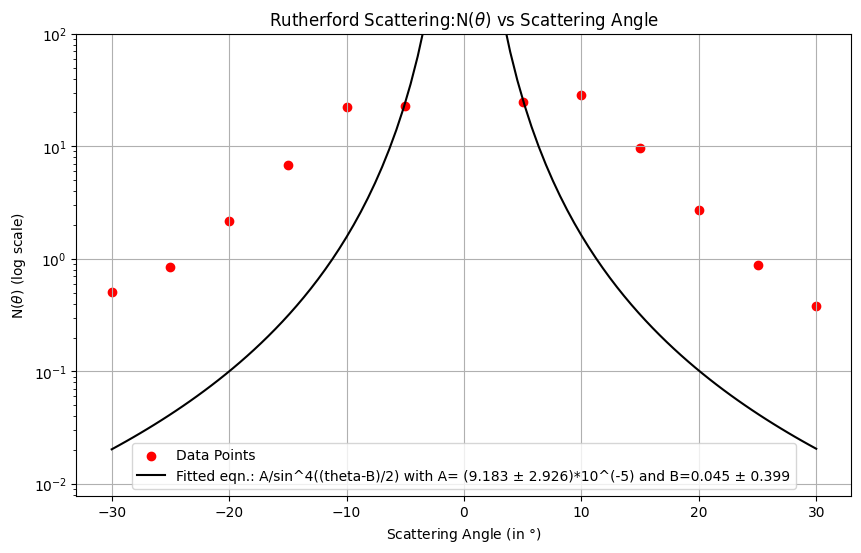

In [4]:
#  Measured values  (with gold foil and slit d = 5 mm): 

theta = [-30,-25,-20,-15, -10,-5, 5, 10,15, 20,25, 30]  # angles in degrees
gate_time = [900,600,200,100,100,100,100,100,100,200,600,900]  # gate times in seconds
counts_ = [147,192, round(np.average([217,191]),1),round(np.average([434,407]),1), round(np.average([2029,2098]),1),round(np.average([4145,4196,4214]),1),round(np.average([4507,4491,4500]),1),round(np.average([2577,2636]),1),round(np.average([568,628]),1),round(np.average([241,263]),1),200,109]  # counts measured at each angle
counts =[]

for i in range(len(theta)):
    counts.append((2*np.pi*abs(np.sin(np.radians(theta[i])))*counts_[i])/gate_time[i])  
ps = [round(counts_[i]/gate_time[i],3) for i in range(len(theta))]
# print('angle(theta in deg.)',theta)
# print('Gate time',gate_time) 
# print('Mean Pulse Count', counts_) # make it list remove np.float things
# print('per sec.',ps)
# print('space-correction',[round((2*np.pi*abs(np.sin(np.radians(theta[i]))))*ps[i],3) for i in range(len(theta))])

def fit_func(theta, A, B):
    return A / np.sin(np.radians((theta - B) / 2))**4

plt.figure(figsize=(10, 6))
plt.scatter(theta, counts, marker='o', color='r',label = 'Data Points')

fit_params = [1000, 0.4]  # initial guess for A and B
popt, pcov = curve_fit(fit_func, theta, counts, p0=fit_params)
theta_fit = np.linspace(min(theta), max(theta), 100)
counts_fit = fit_func(theta_fit, *popt)
error_A = np.sqrt(pcov[0][0])
error_B = np.sqrt(pcov[1][1])
fit_equ = f"A/sin^4((theta-B)/2) with A= ({(popt[0]*10**5):.3f} ± {(error_A*10**5):.3f})*10^(-5) and B={(popt[1]):.3f} ± {error_B:.3f}" # with error in A and B
plt.plot(theta_fit, counts_fit, label='Fitted eqn.: '+fit_equ,color='black')
plt.yscale('log')
plt.ylim(0,1e2)
plt.xlabel(r'Scattering Angle (in $\degree$)')
plt.ylabel(r'N($\theta$) (log scale)')
plt.title(r'Rutherford Scattering:N($\theta$) vs Scattering Angle')
plt.legend()
plt.grid(True)
plt.show()

In [5]:

# determination of nuclear charge

#for Au

t_Au = [-15,15] #  in theta
gt_Au = [100,100] # gate time in s
counts_Au = [round(np.average([29,28,40]),1),round(np.average([35,27,36]),1)]
ps_Au = [round(counts_Au[0]/gt_Au[0],3),round(counts_Au[1]/gt_Au[1],3)] # per sec counts
corr_Au = [round(2*np.pi*np.sin(np.deg2rad(15))*ps_Au[0],3),round(2*np.pi*np.sin(np.deg2rad(15))*ps_Au[1],3)] # space corrected

print('theta of Au',t_Au)
print('gate time of Au',gt_Au)
print('counts of Au',counts_Au)
print('persec of count',ps_Au)
print('space corrected value of Au',corr_Au)

# for Al
t_Al = [-15,15] #  in theta
gt_Al = [1000,1000] # gate time in s
counts_Al = [round(np.average([17,25]),1),round(np.average([30,30]),1)]
ps_Al = [round(counts_Al[0]/gt_Al[0],3),round(counts_Al[1]/gt_Al[1],3)] # per sec counts
corr_Al = [round(2*np.pi*np.sin(np.deg2rad(15))*ps_Al[0],3),round(2*np.pi*np.sin(np.deg2rad(15))*ps_Al[1],3)] # space corrected

print('\n')
print('theta of Al',t_Al)
print('gate time of Al',gt_Al)
print('counts of Al',counts_Al)
print('persec of count',ps_Al)
print('space corrected value of Al',corr_Al)

theta of Au [-15, 15]
gate time of Au [100, 100]
counts of Au [np.float64(32.3), np.float64(32.7)]
persec of count [np.float64(0.323), np.float64(0.327)]
space corrected value of Au [np.float64(0.525), np.float64(0.532)]


theta of Al [-15, 15]
gate time of Al [1000, 1000]
counts of Al [np.float64(21.0), np.float64(30.0)]
persec of count [np.float64(0.021), np.float64(0.03)]
space corrected value of Al [np.float64(0.034), np.float64(0.049)]
